# torchdeform — a visual tour

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/robertpop99/torchdeform/blob/main/examples/tutorial.ipynb)

A step-by-step walk through the library: from a single deformation source to a
full synthetic InSAR dataset, plotting each stage. For the API reference see the
[README](../README.md).

In [1]:
%matplotlib inline
import math
import torch
import numpy as np
import matplotlib.pyplot as plt

import torchdeform
from torchdeform import (MogiSource, PennySource, PCDMSource, OkadaSourceSimple,
                         okada_params_from_fault, los_vector)
from torchdeform.observation.insar import to_phase, wrap_phase
from torchdeform.atmosphere import (turbulent_aps, stratified_aps, orbital_ramp,
                                    correlated_noise_cholesky,
                                    covariance_vs_distance, fit_exponential_covariance)
from torchdeform.simulation import (
    ObservationGrid, SourceGenerator, DeformationGenerator, GeometryGenerator,
    AtmosphereGenerator, InterferogramGenerator, InsarDataset, synthetic_dem,
    UniformPrior, DEFAULT_MOGI_PRIOR, DEFAULT_PENNY_PRIOR, DEFAULT_PCDM_PRIOR,
    DEFAULT_EARTHQUAKE_PRIOR, DEFAULT_S1_GEOMETRY_PRIOR,
)

torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 70          # keep the committed notebook lightweight
print("torchdeform", torchdeform.__version__)

torchdeform 0.1.0


## 0. Grid and plotting helpers

Everything is evaluated on a fixed `ObservationGrid` (East/North metres, centred
on the origin). A small helper reshapes a `[1, N]` field to an image and shows it
with a symmetric (diverging) colour map; wrapped phase uses a cyclic map over
`[-pi, pi]`.

In [2]:
ROWS = COLS = 128
PS = 200.0                                   # metres / pixel
grid = ObservationGrid(ROWS, COLS, psizex=PS, psizey=PS)
x_obs, y_obs = grid.coords(1)                # [1, N] observation coordinates
z = torch.zeros(1)                           # a convenient [1] zero (source at centre)
EXT = [-(COLS - 1) * PS / 2e3, (COLS - 1) * PS / 2e3,
       -(ROWS - 1) * PS / 2e3, (ROWS - 1) * PS / 2e3]    # km, for axes

def field(t):
    """Reshape a [1, N] / [1, H, W] / [N] tensor to an [H, W] numpy array."""
    return t.detach().reshape(ROWS, COLS).cpu().numpy()

def imshow(ax, img, title, cmap="RdBu_r", cyclic=False):
    if cyclic:
        m = ax.imshow(img, extent=EXT, origin="lower", cmap="twilight_shifted",
                      vmin=-math.pi, vmax=math.pi)
    else:
        v = float(np.abs(img).max()) or 1.0
        m = ax.imshow(img, extent=EXT, origin="lower", cmap=cmap, vmin=-v, vmax=v)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(m, ax=ax, fraction=0.046, pad=0.04)

## 1. A single source — Mogi point source

A Mogi source (an inflating/deflating point) produces a radially symmetric
displacement. The models return an ENU `Displacement` (`[B, N]`), differentiable
in every parameter.

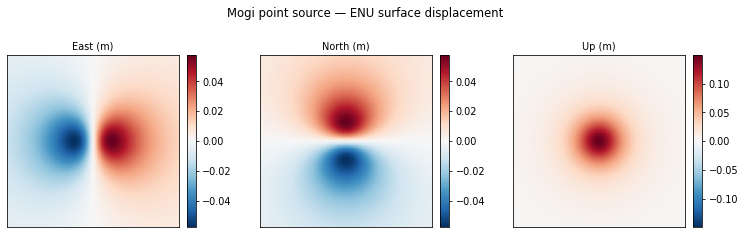

In [3]:
mogi = MogiSource()
disp = mogi(x_obs, y_obs,
            source_x=z, source_y=z,
            depth=torch.tensor([4000.0]), delta_v=torch.tensor([1e7]))

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
imshow(ax[0], field(disp.e), "East (m)")
imshow(ax[1], field(disp.n), "North (m)")
imshow(ax[2], field(disp.u), "Up (m)")
fig.suptitle("Mogi point source — ENU surface displacement", y=1.03)
plt.tight_layout(); plt.show()

## 2. Line-of-sight, phase, and wrapping

InSAR doesn't see ENU — it sees displacement projected onto the radar
line-of-sight, converted to phase and *wrapped* into `[-pi, pi]`. Here: a
Sentinel-1 ascending geometry.

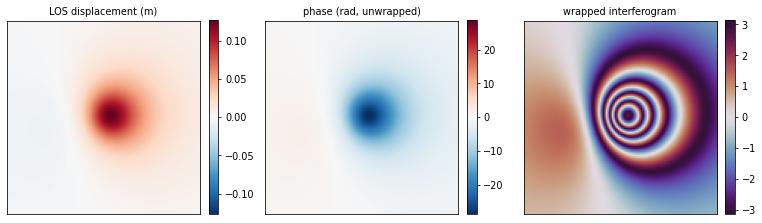

In [4]:
los = los_vector(torch.tensor([-13.0]), torch.tensor([39.0]))   # heading, incidence (deg)
d_los = disp.to_los(los)                                        # [1, N] LOS displacement (m)
phase = to_phase(d_los)                                         # radians (unwrapped)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
imshow(ax[0], field(d_los), "LOS displacement (m)")
imshow(ax[1], field(phase), "phase (rad, unwrapped)")
imshow(ax[2], field(wrap_phase(phase)), "wrapped interferogram", cyclic=True)
plt.tight_layout(); plt.show()

## 3. The source gallery

Every source model, projected to LOS and wrapped. The Okada rectangular fault
covers earthquakes, dykes and sills (just different parameter regimes), and the
penny crack and pCDM add volcanic styles.

(We use moderately deep faults here so the fringes stay legible — a very shallow
rupture packs fringes finer than the pixel spacing, which *aliases* when wrapped,
exactly as real interferograms decorrelate over a surface rupture.)

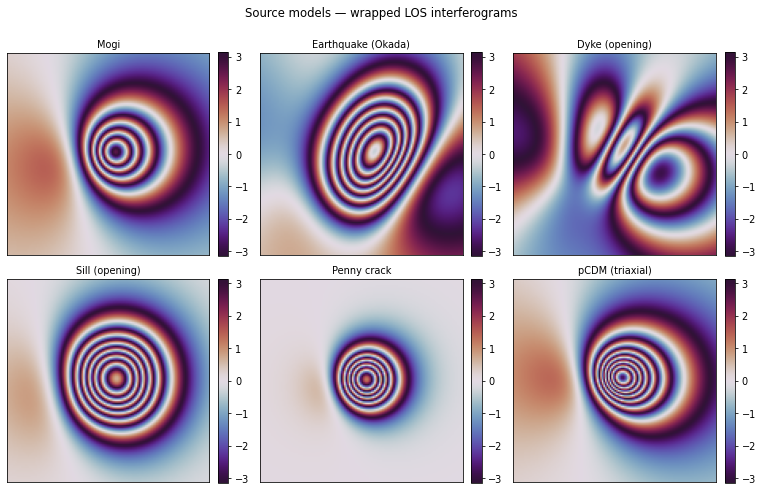

In [5]:
def wrapped_los(d):
    return field(wrap_phase(to_phase(d.to_los(los))))

def okada(strike, dip, rake, slip, opening, top_depth, length, width):
    p = {k: torch.tensor([v]) for k, v in dict(
        strike=strike, dip=dip, rake=rake, slip=slip, opening=opening,
        top_depth=top_depth, length=length, width=width).items()}
    return OkadaSourceSimple()(
        x_obs, y_obs, source_x=z, source_y=z, **okada_params_from_fault(p))

panels = {
    "Mogi": disp,
    "Earthquake (Okada)": okada(30, 45, 90, 1.0, 0.0, 5000, 9000, 6000),
    "Dyke (opening)":     okada(30, 85, 0.0, 0.0, 1.0, 3500, 8000, 5000),
    "Sill (opening)":     okada(0, 5, 0.0, 0.0, 0.6, 5000, 6000, 6000),
    "Penny crack": PennySource()(x_obs, y_obs, source_x=z, source_y=z,
                                 depth=torch.tensor([3000.0]), radius=torch.tensor([2500.0]),
                                 pressure=torch.tensor([5e6])),
    "pCDM (triaxial)": PCDMSource()(x_obs, y_obs, source_x=z, source_y=z,
                                    depth=torch.tensor([4000.0]),
                                    omega_x=torch.tensor([0.3]), omega_y=torch.tensor([-0.2]),
                                    omega_z=torch.tensor([0.5]),
                                    dv_x=torch.tensor([6e6]), dv_y=torch.tensor([3e6]),
                                    dv_z=torch.tensor([9e6])),
}
fig, axs = plt.subplots(2, 3, figsize=(11, 7))
for ax, (name, d) in zip(axs.ravel(), panels.items()):
    imshow(ax, wrapped_los(d), name, cyclic=True)
fig.suptitle("Source models — wrapped LOS interferograms", y=1.0)
plt.tight_layout(); plt.show()

## 4. Atmosphere

A real "no-deformation" interferogram is dominated by atmosphere: a long-wavelength
orbital ramp, a topography-correlated (stratified) delay, and a turbulent screen.
We build each and sum them.

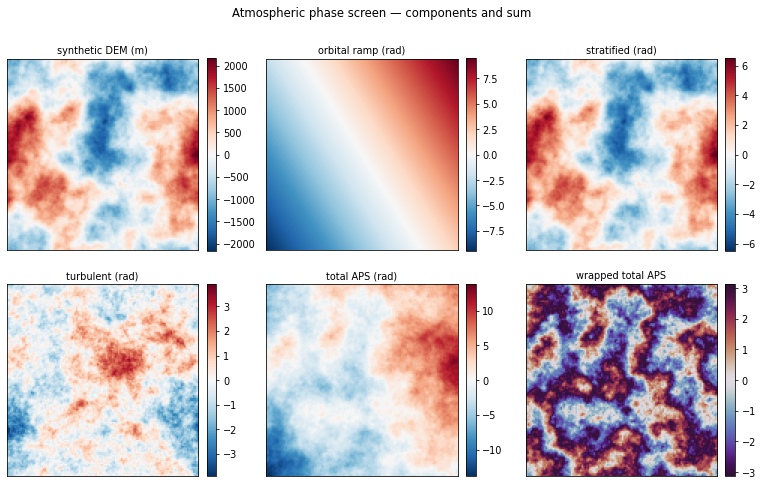

In [6]:
g = torch.Generator().manual_seed(1)
dem   = synthetic_dem(1, ROWS, COLS, relief=800.0, psizex=PS, psizey=PS, generator=g)
orb   = orbital_ramp(1, ROWS, COLS, rms=4.0, generator=g)
strat = stratified_aps(dem, torch.tensor([3e-3]))
turb  = turbulent_aps(1, ROWS, COLS, rms=1.0, psizex=PS, psizey=PS, generator=g)
total = orb + strat + turb

fig, axs = plt.subplots(2, 3, figsize=(11, 7))
imshow(axs[0, 0], field(dem),   "synthetic DEM (m)")
imshow(axs[0, 1], field(orb),   "orbital ramp (rad)")
imshow(axs[0, 2], field(strat), "stratified (rad)")
imshow(axs[1, 0], field(turb),  "turbulent (rad)")
imshow(axs[1, 1], field(total), "total APS (rad)")
imshow(axs[1, 2], field(wrap_phase(total)), "wrapped total APS", cyclic=True)
fig.suptitle("Atmospheric phase screen — components and sum", y=1.0)
plt.tight_layout(); plt.show()

## 5. The full pipeline

`InterferogramGenerator` composes deformation + geometry + atmosphere. The sample
stores the *unwrapped* physical fields; `sample.wrapped()` gives the observable
interferogram. Below: the deformation phase, the atmosphere, their sum, and the
wrapped observable.

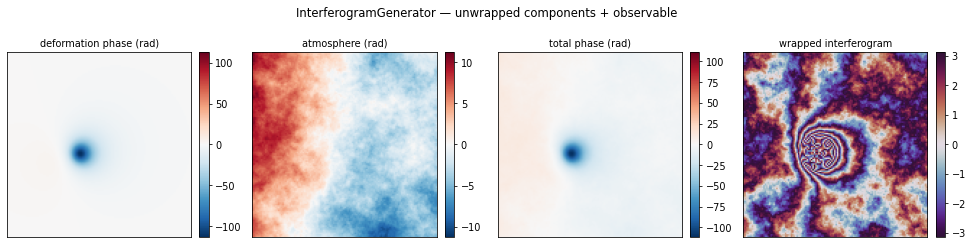

In [7]:
pipeline = InterferogramGenerator(
    deformation=DeformationGenerator(grid, {"mogi": SourceGenerator(MogiSource(), DEFAULT_MOGI_PRIOR)}),
    geometry=GeometryGenerator(DEFAULT_S1_GEOMETRY_PRIOR),
    atmosphere=AtmosphereGenerator(
        grid, orbital_rms=UniformPrior(2.0, 5.0), turbulent_rms=UniformPrior(0.5, 1.5),
        strat_coeff=UniformPrior(-3e-3, 3e-3),
        dem=lambda b, gg: synthetic_dem(b, ROWS, COLS, relief=800.0, psizex=PS, psizey=PS, generator=gg),
    ),
)
s = pipeline.generate(1, generator=torch.Generator().manual_seed(3))

fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
imshow(ax[0], field(s.deformation_phase), "deformation phase (rad)")
imshow(ax[1], field(s.atmosphere),        "atmosphere (rad)")
imshow(ax[2], field(s.phase),             "total phase (rad)")
imshow(ax[3], field(s.wrapped()),         "wrapped interferogram", cyclic=True)
fig.suptitle("InterferogramGenerator — unwrapped components + observable", y=1.03)
plt.tight_layout(); plt.show()

## 6. A batch of random samples (mixture + dataset)

A `DeformationGenerator` picks a source type per item (by weight); wrapping it in
an `InsarDataset` gives reproducible, index-addressable samples for training.
Here are 8 random draws with their source-type labels.

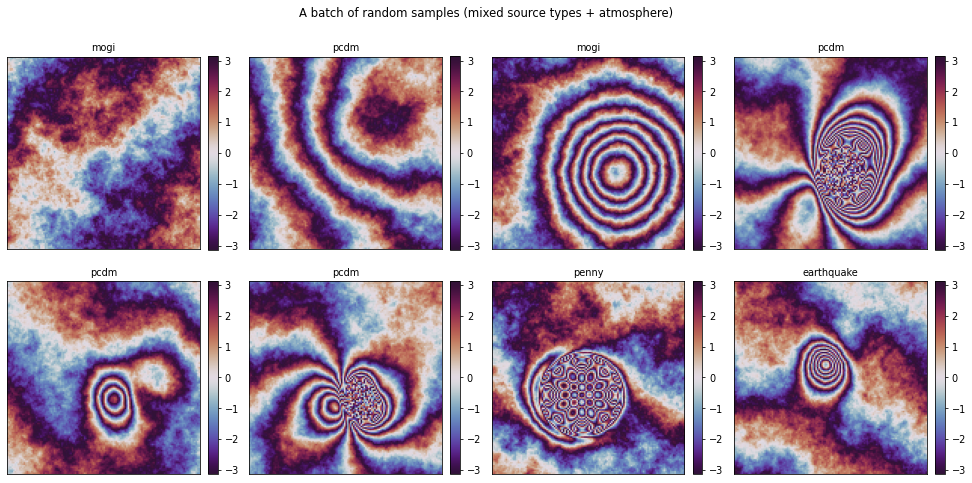

10000 samples; dataset[0].wrapped().shape = (1, 128, 128)


In [8]:
sources = {
    "mogi": SourceGenerator(MogiSource(), DEFAULT_MOGI_PRIOR),
    "earthquake": SourceGenerator(OkadaSourceSimple(),
                                  DEFAULT_EARTHQUAKE_PRIOR, to_forward=okada_params_from_fault),
    "penny": SourceGenerator(PennySource(), DEFAULT_PENNY_PRIOR),
    "pcdm": SourceGenerator(PCDMSource(), DEFAULT_PCDM_PRIOR),
}
pipe = InterferogramGenerator(
    DeformationGenerator(grid, sources),
    GeometryGenerator(DEFAULT_S1_GEOMETRY_PRIOR),
    AtmosphereGenerator(grid, orbital_rms=UniformPrior(2.0, 4.0), turbulent_rms=UniformPrior(0.5, 1.0)),
)
batch = pipe.generate(8, generator=torch.Generator().manual_seed(7))
w = batch.wrapped()                                   # [8, ROWS, COLS]

fig, axs = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axs.ravel()):
    imshow(ax, w[i].cpu().numpy(), batch.deformation.source_type[i], cyclic=True)
fig.suptitle("A batch of random samples (mixed source types + atmosphere)", y=1.0)
plt.tight_layout(); plt.show()

# the same generator wrapped as an index-addressable, reproducible Dataset:
dataset = InsarDataset(pipe, length=10_000)
print(len(dataset), "samples; dataset[0].wrapped().shape =", tuple(dataset[0].wrapped().shape))

## 7. Calibrating the atmosphere from data

`covariance_vs_distance` + `fit_exponential_covariance` recover the variance and
correlation length of a screen — so you can match the generator to a real scene
(or validate it). Here we synthesise an exponential field and fit it back.

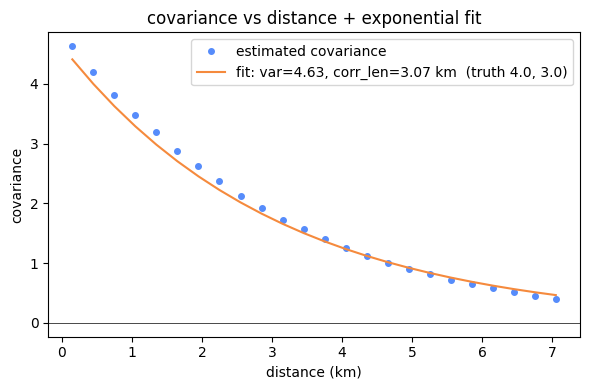

In [9]:
f = correlated_noise_cholesky(48, 48, maxvar=4.0, alpha=1 / 3000.0, N=32,
                              psizex=300.0, psizey=300.0,
                              generator=torch.Generator().manual_seed(0))
d, cov = covariance_vs_distance(f, psizex=300.0, psizey=300.0, demean=False)
var, cl = fit_exponential_covariance(f, psizex=300.0, psizey=300.0, demean=False)
cov_m = cov.mean(0)                       # average the per-realization curves
var_m, cl_m = var.mean(), cl.mean()       # per-realization fits -> mean estimate

d_km = (d / 1000).numpy()
plt.figure(figsize=(6, 4))
plt.plot(d_km, cov_m.numpy(), "o", ms=4, label="estimated covariance")
plt.plot(d_km, (var_m * torch.exp(-d / cl_m)).numpy(), "-",
         label=f"fit: var={var_m.item():.2f}, corr_len={cl_m.item()/1000:.2f} km  (truth 4.0, 3.0)")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("distance (km)"); plt.ylabel("covariance")
plt.title("covariance vs distance + exponential fit"); plt.legend()
plt.tight_layout(); plt.show()